In [49]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Step 1: Load and inspect the data
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head())



   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [40]:
# Step 1: Load and inspect the data
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [41]:
# Step 2: Data preprocessing and feature creation
# Drop customerID as it is not a predictive feature
df.drop(['customerID'], axis=1, inplace=True)

In [42]:
# Convert TotalCharges to numeric and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Define the time horizon
time_horizon = 12  # example time horizon in months
df = df[df['tenure'] >= time_horizon]

In [43]:
# Encode categorical variables and scale numerical variables
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features.remove('tenure')  # Exclude 'tenure' from scaling

# One-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

In [44]:
# Define target variable and features
X = df.drop(['tenure'], axis=1)
y = df['tenure']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

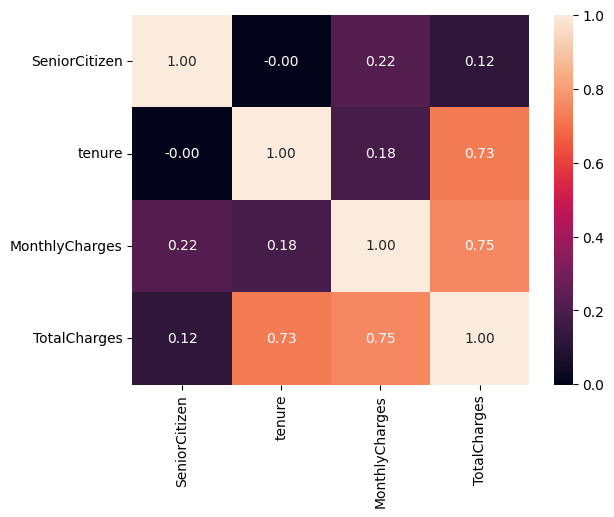

In [45]:
# Step 3: Exploratory data analysis
# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numerical_df.corr(), annot=True, fmt='.2f')
plt.show()


In [46]:
# Step 4: Model testing by train-test or cross-validation
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    results[name] = np.mean(scores)


In [47]:
# Step 5: Evaluation of the ex-post model
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Mean CV MSE'])
results_df.sort_values(by='Mean CV MSE', ascending=False, inplace=True)
print(results_df)

# Detailed model evaluation
detailed_results = pd.DataFrame(columns=['Model', 'MSE', 'RMSE', 'MAE', 'R²'])

# Function to evaluate the model
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return pd.DataFrame({
        'Model': [name],
        'MSE': [mse],
        'RMSE': [rmse],
        'MAE': [mae],
        'R²': [r2]
    })

                   Mean CV MSE
Neural Network       -2.440290
Random Forest        -3.345535
Gradient Boosting    -5.275066
Decision Tree        -7.026530
Linear Regression   -59.693672


                         MSE      RMSE       MAE        R²
Model                                                     
Linear Regression  51.734335  7.192658  5.339905  0.861333
Decision Tree       5.274372  2.296600  1.660302  0.985863
Random Forest       2.677118  1.636190  1.198683  0.992824
Gradient Boosting   5.086913  2.255419  1.710453  0.986365
Neural Network      2.185700  1.478411  1.122141  0.994142


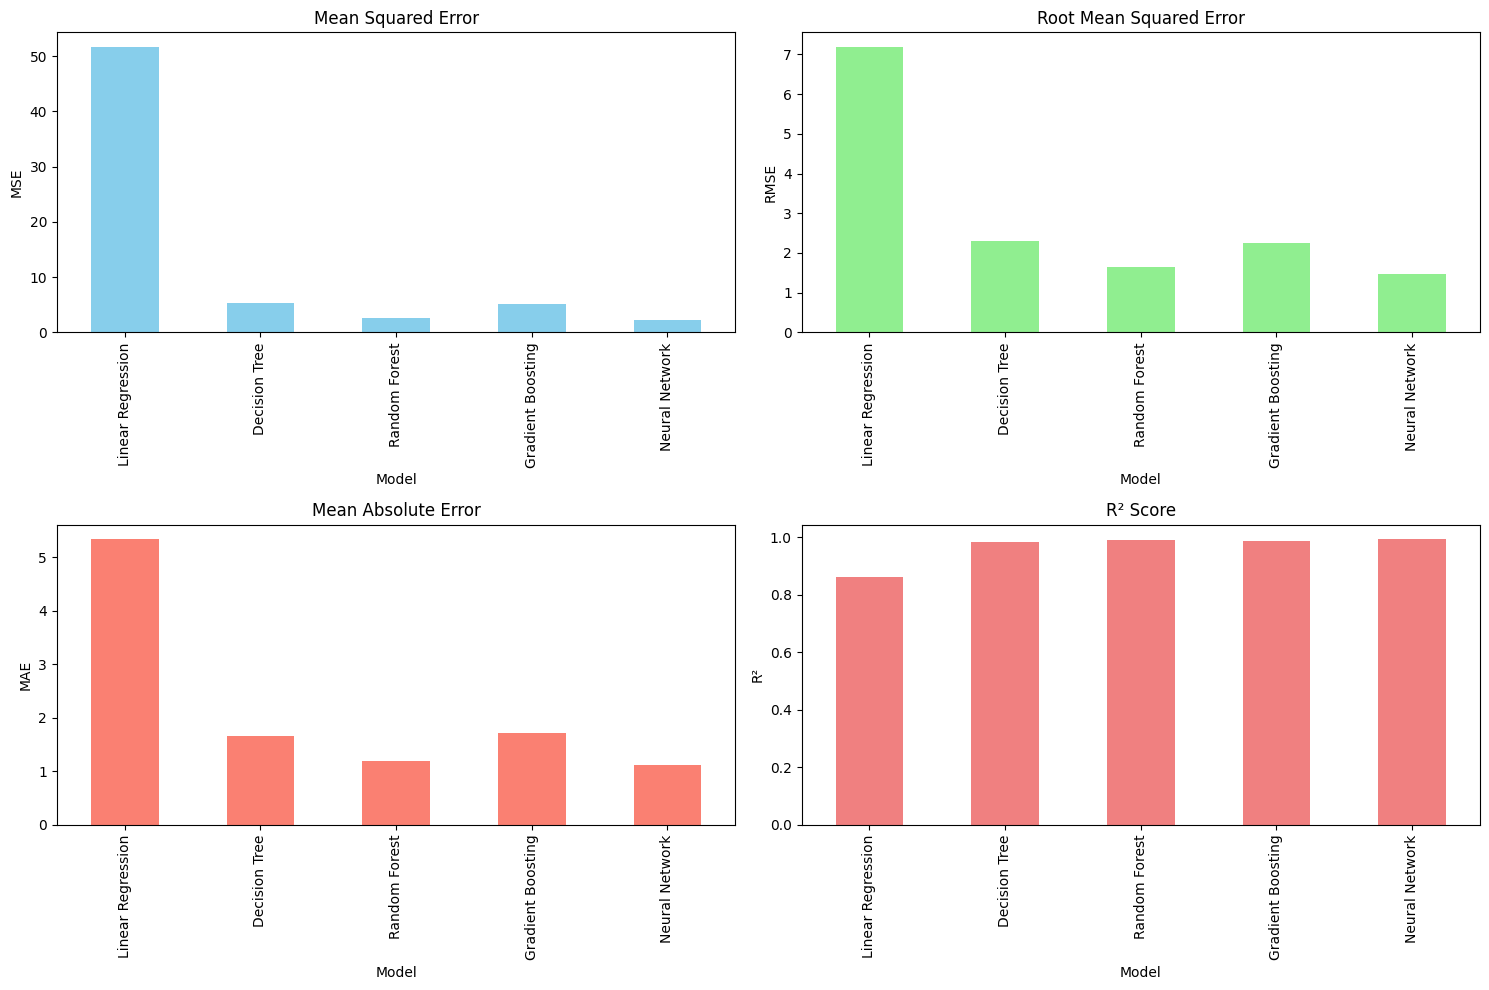

In [48]:
# Evaluate each model
for name, model in models.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    detailed_results = pd.concat([detailed_results, result], ignore_index=True)

# Display the detailed results
detailed_results.set_index('Model', inplace=True)
print(detailed_results)

# Visualize the results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot MSE
detailed_results['MSE'].plot(kind='bar', ax=axes[0, 0], title='Mean Squared Error', color='skyblue')
axes[0, 0].set_ylabel('MSE')

# Plot RMSE
detailed_results['RMSE'].plot(kind='bar', ax=axes[0, 1], title='Root Mean Squared Error', color='lightgreen')
axes[0, 1].set_ylabel('RMSE')

# Plot MAE
detailed_results['MAE'].plot(kind='bar', ax=axes[1, 0], title='Mean Absolute Error', color='salmon')
axes[1, 0].set_ylabel('MAE')

# Plot R²
detailed_results['R²'].plot(kind='bar', ax=axes[1, 1], title='R² Score', color='lightcoral')
axes[1, 1].set_ylabel('R²')

plt.tight_layout()
plt.show()